# Codveda Technologies — Level 3, Task 2
## Support Vector Machine (SVM) for Classification

**Dataset:** Iris

### Objectives
1. Prepare the dataset for SVM classification
2. Standardize numerical features
3. Train and compare **Linear** and **RBF** SVM kernels
4. Evaluate the models using accuracy, precision, and recall
5. Visualize an SVM decision boundary in two dimensions
6. Evaluate the selected model using multiclass ROC-AUC

### Important note
The Iris dataset contains **three classes**. The full four-feature dataset is used for model evaluation. A two-feature version is used separately for the decision-boundary visualization because a decision boundary cannot be visualized directly in four dimensions.


## 1. Import Required Libraries

In [ ]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    roc_auc_score
)


## 2. Load the Dataset




In [ ]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

DATA_PATH = "datasets/1) iris.csv"

df = pd.read_csv("/content/1) iris.csv")

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

display(df.head())


Dataset loaded successfully.
Rows: 150
Columns: 5


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 3. Initial Data Inspection

In [ ]:
# ============================================================
# 3. INITIAL DATA INSPECTION
# ============================================================

print("Dataset information:")
df.info()

print("\nMissing values:")
display(df.isna().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nClass distribution:")
display(df.iloc[:, -1].value_counts())


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Missing values:


,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0



Duplicate rows:
3

Class distribution:


,count
species,
setosa,50
versicolor,50
virginica,50


## 4. Remove Duplicate Observations

Duplicate records are removed before splitting the dataset so that identical observations do not appear in both training and testing data.


In [ ]:
# ============================================================
# 4. REMOVE DUPLICATES
# ============================================================

duplicates = df.duplicated().sum()

df = df.drop_duplicates().reset_index(drop=True)

print(f"Duplicate rows removed: {duplicates}")
print(f"New dataset shape: {df.shape}")


Duplicate rows removed: 3
New dataset shape: (147, 5)


## 5. Define Features and Target

The final column is the species/class label. It is separated from the four numerical measurements.


In [ ]:
# ============================================================
# 5. DEFINE FEATURES AND TARGET
# ============================================================

target_column = "species" if "species" in df.columns else df.columns[-1]

X = df.drop(columns=[target_column])
y = df[target_column]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(target_column)


Features:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

Target:
species


## 6. Encode the Target

SVM requires numerical class labels. `LabelEncoder` converts the three species labels into `0`, `1`, and `2`.

The target is encoded separately from the input features.


In [ ]:
# ============================================================
# 6. ENCODE TARGET
# ============================================================

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Class mapping:")
for class_name, encoded_value in zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
):
    print(f"{class_name} -> {encoded_value}")


Class mapping:
setosa -> 0
versicolor -> 1
virginica -> 2


## 7. Train/Test Split

Stratification preserves the class proportions in both subsets.


In [ ]:
# ============================================================
# 7. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print(f"Training set: {X_train.shape}")
print(f"Testing set:  {X_test.shape}")


Training set: (117, 4)
Testing set:  (30, 4)


## 8. Standardize the Features

SVM is sensitive to feature scale because its optimization depends on distances and margins.

**Important:** the scaler is fitted only on the training set.


In [ ]:
# ============================================================
# 8. FEATURE STANDARDIZATION
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature standardization completed.")


Feature standardization completed.


## 9. Train Linear and RBF SVM Models

- **Linear kernel:** creates a linear decision boundary.
- **RBF kernel:** can create nonlinear decision boundaries.

We evaluate both on the same unseen test set.


In [ ]:
# ============================================================
# 9. TRAIN AND COMPARE SVM KERNELS
# ============================================================

models = {
    "Linear SVM": SVC(kernel="linear", probability=True, random_state=42),
    "RBF SVM": SVC(kernel="rbf", probability=True, random_state=42)
}

results = []

for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(
        y_test, predictions, average="macro", zero_division=0
    )
    recall = recall_score(
        y_test, predictions, average="macro", zero_division=0
    )

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall
    })

results_df = pd.DataFrame(results)

display(results_df.round(4))


,Model,Accuracy,Precision,Recall
0,Linear SVM,1.0000,1.0000,1.0000
1,RBF SVM,0.9667,0.9697,0.9667


## 10. Classification Report for the Selected Model

In [ ]:
# ============================================================
# 10. SELECT BEST MODEL AND PRINT CLASSIFICATION REPORT
# ============================================================

best_model_name = results_df.sort_values(
    by="Accuracy",
    ascending=False
).iloc[0]["Model"]

best_model = models[best_model_name]

y_pred = best_model.predict(X_test_scaled)

print(f"Selected model: {best_model_name}\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)


Selected model: Linear SVM

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## 11. Visualize the SVM Decision Boundary

A two-feature model is trained specifically for visualization. This does **not** replace the full four-feature evaluation above.

The visualization uses the two petal measurements because they provide a useful two-dimensional representation of the Iris classes.


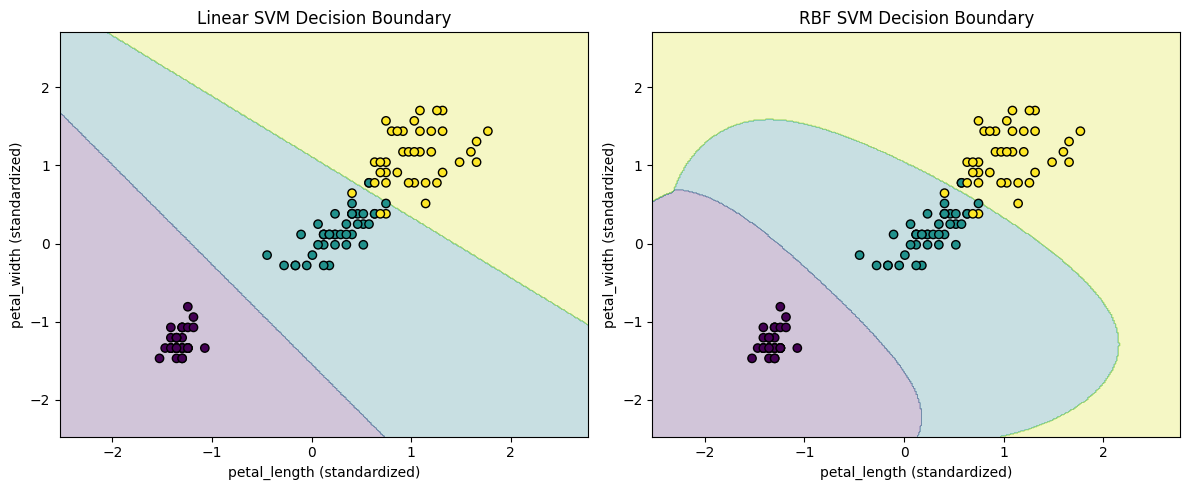

In [ ]:
# ============================================================
# 11. DECISION BOUNDARY VISUALIZATION
# ============================================================

petal_columns = [
    column for column in X.columns
    if "petal" in column.lower()
]

if len(petal_columns) < 2:
    petal_columns = X.columns[-2:].tolist()

X_2d = X[petal_columns]

X_2d_train, X_2d_test, y_2d_train, y_2d_test = train_test_split(
    X_2d,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

scaler_2d = StandardScaler()

X_2d_train_scaled = scaler_2d.fit_transform(X_2d_train)

linear_2d = SVC(kernel="linear", probability=True, random_state=42)
rbf_2d = SVC(kernel="rbf", probability=True, random_state=42)

linear_2d.fit(X_2d_train_scaled, y_2d_train)
rbf_2d.fit(X_2d_train_scaled, y_2d_train)

x_min = X_2d_train_scaled[:, 0].min() - 1
x_max = X_2d_train_scaled[:, 0].max() + 1
y_min = X_2d_train_scaled[:, 1].min() - 1
y_max = X_2d_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, model, title in [
    (axes[0], linear_2d, "Linear SVM"),
    (axes[1], rbf_2d, "RBF SVM")
]:
    grid_predictions = model.predict(
        np.c_[xx.ravel(), yy.ravel()]
    ).reshape(xx.shape)

    ax.contourf(
        xx,
        yy,
        grid_predictions,
        alpha=0.25
    )

    scatter = ax.scatter(
        X_2d_train_scaled[:, 0],
        X_2d_train_scaled[:, 1],
        c=y_2d_train,
        edgecolors="black"
    )

    ax.set_title(f"{title} Decision Boundary")
    ax.set_xlabel(f"{petal_columns[0]} (standardized)")
    ax.set_ylabel(f"{petal_columns[1]} (standardized)")

plt.tight_layout()
plt.show()


## 12. Multiclass ROC-AUC

Because Iris has three classes, ROC-AUC is calculated using the **one-vs-rest (OVR)** approach.


In [ ]:
# ============================================================
# 12. MULTICLASS ROC-AUC
# ============================================================

y_probability = best_model.predict_proba(X_test_scaled)

auc_score = roc_auc_score(
    y_test,
    y_probability,
    multi_class="ovr",
    average="macro"
)

print(f"Multiclass ROC-AUC (OVR): {auc_score:.4f}")


Multiclass ROC-AUC (OVR): 1.0000


## 13. Final Summary

This task demonstrates the complete SVM workflow:

- Dataset inspection
- Target encoding
- Stratified train/test split
- Feature standardization
- Linear SVM
- RBF SVM
- Accuracy, precision, and recall
- Two-dimensional decision-boundary visualization
- Multiclass ROC-AUC
